# Figure 2: Plasmid selectivity

Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Transfected with minipreps



Reps:
- 2026.06.29: 20k/well (1 reps)
- 2026.07.02: 20k/well (2 reps)


**Load in packages**

In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.ticker import NullLocator
from matplotlib.patches import Patch

**Stats functions**

In [2]:
# Convert p-value to significance stars
def p_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'


# Function for drawing brackets
def add_sig_bracket(ax, x1, x2, y, h, p):
    
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        color='black',
        linewidth=1,
        clip_on=False
    )
    
    ax.text(
        (x1 + x2) / 2,
        y + h,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=9
    )


## Load Data from location

In [3]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.29_exp57': ['Plate1'],
          '2026.07.02_exp60': ['Plate1', 'Plate2']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'Figure_2_selectivity'
cache_path = rd.rootdir/'output'/'Figure_2_selectivity'/'data_plasmid.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


**Load in Dataframe**

In [4]:
#Load data
data = pd.DataFrame()
if cache_path.exists():
    data = pd.read_parquet(rd.outfile(cache_path))
else:
    channel_list = ['mRuby2-H','mGL-H','iRFP670-H', 'FSC-A', 'TagBFP-H']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [5]:
data['conds'] = data['reporter'] +'.'+ data['Plasmid'] 
display(data)

,reporter,Puro,Puro#,Plasmid,Deliver,Date,well,population,FSC-A,mGL-H,iRFP670-H,TagBFP-H,mRuby2-H,conds
0,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,346898,86,83,69,78,Controls.0x
1,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,246866,73,8038,84,2151,Controls.0x
2,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,225904,92,1042,79,60,Controls.0x
3,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,442587,76,180,89,110,Controls.0x
4,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,334906,221,22276,236,31478,Controls.0x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984272,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,298796,50,109,71,88,pKG05003.0.1x
14984273,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,165894,103,64,47,46,pKG05003.0.1x
14984274,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,350031,103,74,69,81,pKG05003.0.1x
14984275,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,451891,32,31,89,24,pKG05003.0.1x


**Untransfected data**

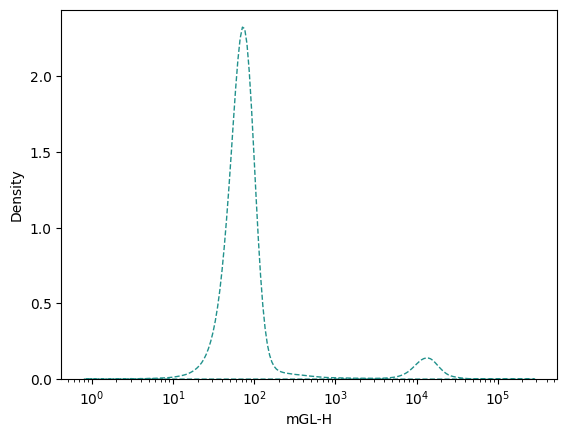

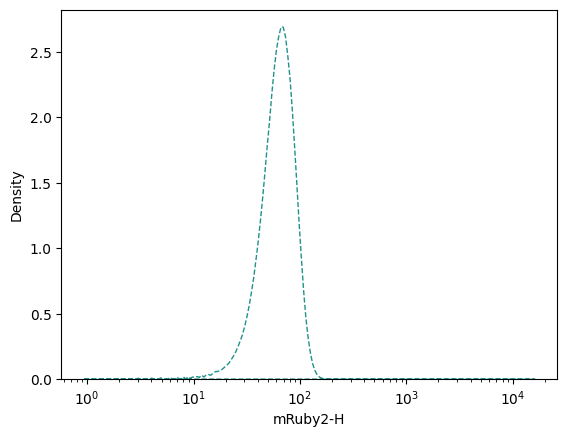

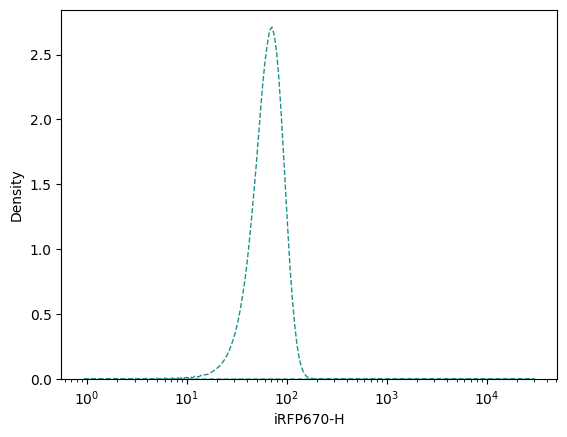

In [6]:
parameters = np.array(['mGL-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['reporter'] == 'Untransfected') & (data[param] > 0 )]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

**Set gates for FPs**

In [7]:
# Set gates for data analysis

# Or use the percentile gating
iRFP_gate_quantile = untransfected['iRFP670-H'].quantile(0.99)
eGFP_gate = 3000
mRuby_gate = 500

# # Gating on co-transfection marker
data_gated = data[data['iRFP670-H'] > iRFP_gate_quantile]
data_eGFP = data[data['mGL-H'] > eGFP_gate]

## Gating for FP+ cells

**Gating for mRuby2 and EGFP**

In [8]:
mRuby2_gated = data[data['mRuby2-H'] > mRuby_gate].copy()
Double_gated = mRuby2_gated[mRuby2_gated['iRFP670-H'] > iRFP_gate_quantile].copy() 

In [9]:
mRuby2_gated['eGFP_cat'] = np.where(mRuby2_gated['mGL-H'] > eGFP_gate, 'eGFP+', 'eGFP-') 

In [10]:
well_group = ['conds']
count_df = mRuby2_gated.groupby(['conds','reporter', 'Date','eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_mRuby2 = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_mRuby2 = count_df.reset_index()
display(percent_small_data_1_mRuby2)

,conds,reporter,Date,eGFP_cat,percent
0,Controls.0x,Controls,2026.06.29.x,eGFP+,7.390089
1,Controls.0x,Controls,2026.06.29.x,eGFP-,92.609911
2,Untransfected.0x,Untransfected,2026.06.29.x,eGFP+,0.000000
3,Untransfected.0x,Untransfected,2026.06.29.x,eGFP-,100.000000
4,pKG04405.0.5x,pKG04405,2026.06.29.x,eGFP+,0.000000
...,...,...,...,...,...
95,pKG05003.1x,pKG05003,2026.06.29.x,eGFP-,19.628324
96,pKG05003.1x,pKG05003,2026.07.02.x,eGFP+,3.188236
97,pKG05003.1x,pKG05003,2026.07.02.x,eGFP-,36.578712
98,pKG05003.1x,pKG05003,2026.07.02.xx,eGFP+,3.127296


## Figure 2 - Fluorescent Selectivity

**Figure 2C**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_35544\901023334.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_35544\901023334.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lmap[cond] for cond in order])


wtNB vs desNB: t = -1.0079281885294917, p = 0.3705106748335141


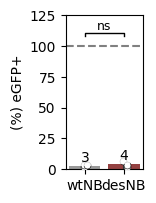

In [13]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = ['pKG05003.1x', 'pKG05002.1x']
eGFP_cat = 'eGFP+'

df = percent_small_data_1_mRuby2.loc[(percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat)]

palette = {
    'pKG05002.1x': 'darkred', 
    'pKG05003.1x': 'grey'
}
fig, ax = plt.subplots(1, 1, figsize=(1,2))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)

# ---------------------------------------------------------
# Statistics: wtNB vs desNB
# ---------------------------------------------------------

from scipy.stats import ttest_ind

wtNB = df.loc[
    df['conds'] == 'pKG05003.1x',
    y
].dropna()

desNB = df.loc[
    df['conds'] == 'pKG05002.1x',
    y
].dropna()

# Two-sided independent Student's t-test
t_stat, p_val = ttest_ind(
    wtNB,
    desNB,
    equal_var=True,
    alternative='two-sided'
)

print(
    f"wtNB vs desNB: "
    f"t = {t_stat}, "
    f"p = {p_val}"
)
# ---------------------------------------------------------
# Add significance bracket
# ---------------------------------------------------------

add_sig_bracket(
    ax,
    0,
    1,
    y=108,
    h=3,
    p=p_val
)

lmap = {
    'pKG05003.1x': 'wtNB', 
    'pKG05002.1x': 'desNB'
}
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 125))
plt.axhline(y=100, color='grey', linestyle= '--')
ax.yaxis.set_label_text('(%) eGFP+')
# ax.set_title('mRuby2+ | 4 dpi (Lenti) | new plasmids')
ax.set_xlabel('')

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

plottitle = 'Figure_2C_plasmid.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**Figure 2C (no stats)**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_37420\1781730017.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_37420\1781730017.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


wtNB mean = 2.70%
desNB mean = 4.09%
Fold change (desNB / wtNB) = 1.52x


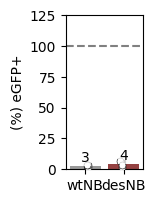

In [13]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = ['pKG05003.1x', 'pKG05002.1x']
eGFP_cat = 'eGFP+'

df = percent_small_data_1_mRuby2.loc[
    percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat
]

palette = {
    'pKG05002.1x': 'darkred', 
    'pKG05003.1x': 'grey'
}

fig, ax = plt.subplots(1, 1, figsize=(1,2))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax,
    data=df,
    x=x,
    y=y,
    order=order,
    palette=palette,
    alpha=0.8
)

sns.stripplot(
    ax=ax,
    data=df,
    x=x,
    y=y,
    order=order,
    dodge=True,
    color='white',
    size=5,
    edgecolor='black',
    linewidth=0.4,
)


# ---------------------------------------------------------
# Calculate fold change: desNB / wtNB
# ---------------------------------------------------------

wtNB_mean = df.loc[
    df['conds'] == 'pKG05003.1x',
    y
].mean()

desNB_mean = df.loc[
    df['conds'] == 'pKG05002.1x',
    y
].mean()

fold_change = desNB_mean / wtNB_mean

print(
    f"wtNB mean = {wtNB_mean:.2f}%"
)

print(
    f"desNB mean = {desNB_mean:.2f}%"
)

print(
    f"Fold change (desNB / wtNB) = {fold_change:.2f}x"
)


# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

lmap = {
    'pKG05003.1x': 'wtNB', 
    'pKG05002.1x': 'desNB'
}

ax.set_xticklabels(
    [lmap[cond] for cond in order]
)

ax.set_ylim((0, 125))

plt.axhline(
    y=100,
    color='grey',
    linestyle='--'
)

ax.yaxis.set_label_text('(%) eGFP+')

ax.set_xlabel('')


# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:

        bar_labels = sub_ax.bar_label(
            i,
            fmt='%0.0f',
            padding=1
        )

        for label in bar_labels:
            label.set_bbox(
                dict(
                    facecolor='white',
                    alpha=0.75,
                    linewidth=0,
                    pad=1
                )
            )


plottitle = 'Figure_2C_plasmid.svg'

plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches='tight'
)

## Contours

**Figure S4C**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_42484\3612107156.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


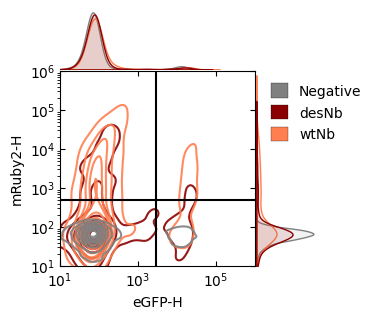

In [11]:
# General plotting params
x = "mGL-H"
y = "mRuby2-H"
hue = "conds"


hue_order = ['pKG05002.1x', 'pKG05003.1x','Untransfected.0x']

# Conditions

palette = {
    'pKG05002.1x': 'darkred', 
    'pKG05003.1x': 'coral',
    'Untransfected.0x': 'grey'
}

# Conditions
data_new = data[(data['mGL-H'] > 0) & (data['mRuby2-H'] > 0)]
untransfected = data[(data['reporter'] == 'Untransfected.0x') & (data['mGL-H'] > 0 ) & (data['mRuby2-H'] > 0)]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new, untransfected])
small_data= small_data.groupby('reporter').sample(n=5000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# h,l = ax_histx.get_legend_handles_labels()
# sns.move_legend(ax_histx, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=0.2,
          label='Negative'),
    Patch(facecolor='darkred', edgecolor='black', linewidth=0.2,
          label='desNb'),
    Patch(facecolor='coral', edgecolor='black', linewidth=0.2,
          label='wtNb')
]

ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
ax_scatter.axhline(mRuby_gate, 0, 1, color='black')
ax_scatter.set_xlabel('eGFP-H')

fig.tight_layout()  # Helps improve white spacing

plottitle = '4dpi_mRuby2_constructs_gated_iRFP_plasmid.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')